<a href="https://colab.research.google.com/github/vishnu123434/AIML_PROJECTS/blob/main/LeNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


In [ ]:
import os

# Specify the path to the folder you want to read
folder_path = 'C:\\Users\\kommu\\OneDrive\\Desktop\\JUPYTER\\hurricane'

# List contents of the folder
folder_contents = os.listdir(folder_path)

# Print the paths of files or subdirectories in the folder
for item in folder_contents:
    item_path = os.path.join(folder_path, item)
    print(item_path)




C:\Users\kommu\OneDrive\Desktop\JUPYTER\hurricane\.ipynb_checkpoints
C:\Users\kommu\OneDrive\Desktop\JUPYTER\hurricane\EXP5.ipynb
C:\Users\kommu\OneDrive\Desktop\JUPYTER\hurricane\test
C:\Users\kommu\OneDrive\Desktop\JUPYTER\hurricane\test_another
C:\Users\kommu\OneDrive\Desktop\JUPYTER\hurricane\train_another
C:\Users\kommu\OneDrive\Desktop\JUPYTER\hurricane\validation_another


In [ ]:
from PIL import Image
import os
import numpy as np

def load_Images(path, x, grayscale=False):
    imgs = []
    labels = []
    l1 = os.listdir(path)

    for i in l1:
        l2 = os.listdir(os.path.join(path, i))
        c = 0
        for j in l2:
            if c > 900:
                break
            img = Image.open(os.path.join(path, i, j))
            img = img.resize(size=(x, x))
            if grayscale:
                img = img.convert("L")
                img = np.array(img, dtype=np.float16) / 255
                img = img.reshape(img.shape[0], img.shape[1], 1)
            else:
                img = np.array(img, dtype=np.float16) / 255
            imgs.append(np.array(img))
            labels.append(i)
            c += 1
            del img

    return np.array(imgs), labels


In [ ]:
x_train,y_train=load_Images(folder_path+"/train_another",28,True)

In [ ]:
x_test,y_test=load_Images(folder_path+"/train_another",28,True)

In [ ]:
x_train.shape

(1802, 28, 28, 1)

In [ ]:
len(y_train)

1802

In [ ]:
x_test.shape

(1802, 28, 28, 1)

In [ ]:
len(y_test)

1802

In [ ]:
t_train = pd.Series(y_train,dtype='category')
t_train = t_train.cat.codes
t_test = pd.Series(y_test,dtype='category')
t_test = t_test.cat.codes
len(t_test)

1802

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

model = Sequential()
model.add(Conv2D(filters=6, kernel_size=5, strides=1, activation='tanh', input_shape=(28, 28, 1), padding='same'))
# S2 Pooling Layer
model.add(AveragePooling2D(pool_size=2, strides=1, padding='valid'))
# C3 Convolutional layer
model.add(Conv2D(filters=16, kernel_size=5, strides=1, activation='tanh', padding='valid'))
# S4 Pooling layer
model.add(AveragePooling2D(pool_size=2, strides=2))
# C4 Convolutional Layer
model.add(Conv2D(filters=126, kernel_size=5, strides=1, activation='tanh', padding='valid'))
model.add(Flatten())
# Fully connected Layer
model.add(Dense(units=84, activation='tanh'))
# Output Layer with softmax activation
model.add(Dense(units=2, activation='softmax'))


In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 6)         156       
                                                                 
 average_pooling2d (Average  (None, 27, 27, 6)         0         
 Pooling2D)                                                      
                                                                 
 conv2d_1 (Conv2D)           (None, 23, 23, 16)        2416      
                                                                 
 average_pooling2d_1 (Avera  (None, 11, 11, 16)        0         
 gePooling2D)                                                    
                                                                 
 conv2d_2 (Conv2D)           (None, 7, 7, 126)         50526     
                                                                 
 flatten (Flatten)           (None, 6174)              0

In [ ]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
history = model.fit(x_train,t_train,batch_size=10,epochs=20,validation_data=(x_test,t_test))

Epoch 1/20


181/181 [==============================] - 8s 30ms/step - loss: 0.5550 - accuracy: 0.7264 - val_loss: 0.4784 - val_accuracy: 0.7825
Epoch 2/20
181/181 [==============================] - 5s 28ms/step - loss: 0.5188 - accuracy: 0.7569 - val_loss: 0.4765 - val_accuracy: 0.7941
Epoch 3/20
181/181 [==============================] - 5s 27ms/step - loss: 0.5027 - accuracy: 0.7531 - val_loss: 0.5161 - val_accuracy: 0.7242
Epoch 4/20
181/181 [==============================] - 5s 26ms/step - loss: 0.4871 - accuracy: 0.7764 - val_loss: 0.4724 - val_accuracy: 0.7808
Epoch 5/20
181/181 [==============================] - 5s 27ms/step - loss: 0.4775 - accuracy: 0.7752 - val_loss: 0.4457 - val_accuracy: 0.8019
Epoch 6/20
181/181 [==============================] - 5s 25ms/step - loss: 0.4711 - accuracy: 0.7858 - val_loss: 0.4349 - val_accuracy: 0.7991
Epoch 7/20
181/181 [==============================] - 5s 26ms/step - loss: 0.4688 - accuracy: 0.7819 - val_loss: 0.4426 - val_accuracy: 0.80

57/57 - 1s - loss: 0.1005 - accuracy: 0.9723 - 666ms/epoch - 12ms/step


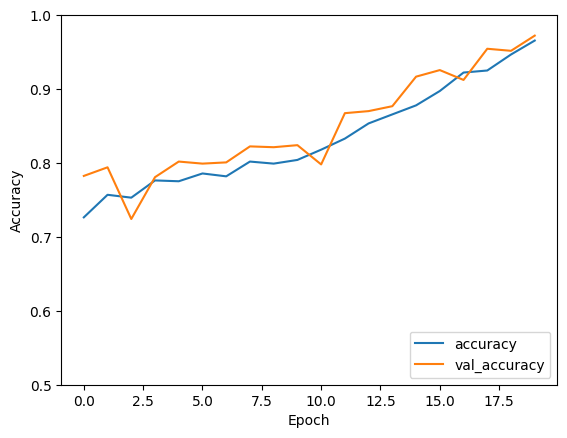

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(x_test,t_test, verbose=2)

In [ ]:
test_loss, test_acc = model.evaluate(x_test,t_test, verbose=2)

57/57 - 1s - loss: 0.1005 - accuracy: 0.9723 - 653ms/epoch - 11ms/step


In [ ]:
print("Test accuracy is ",test_acc,end=", ")
print("Test loss is ",test_loss)

Test accuracy is  0.9722530245780945, Test loss is  0.10050246119499207
